# Análisis Inferencial con Algoritmo Predictivo

> Agregar bloque entrecomillado


## Dataset: Emergencias · Hospital General Dr. Vinicio Calventi (HGDVC) · 2021–2025
**Fuente:** https://hospitalcalventi.gob.do/transparencia/index.php/publicacion-portal-datos-abiertos/category/756-2022?download=6063:emergencia-2021-2025

---
## Pregunta de Investigación
> **¿Es posible predecir si un paciente de emergencia será hospitalizado o dado de alta (estabilizado y despachado), basándose en su edad, género, nacionalidad, especialidad y diagnóstico?**

**Hipótesis:** Las variables clínicas y demográficas disponibles en el registro de emergencias permiten predecir con precisión aceptable (AUC > 0.80) si un paciente será hospitalizado.

**Algoritmo seleccionado:** Random Forest Classifier — robusto ante datos desbalanceados, maneja variables categóricas y permite interpretar la importancia de cada variable predictora.

## Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import LabelEncoder

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## Dataset

In [ ]:
file_path = "EMERGENCIA 2021-2025.xlsx"
df = pd.read_excel(file_path)

print('Shape original:', df.shape)
df.head()

Shape original: (273054, 8)


,FECHA,NACIONALIDAD,EDAD,GÉNERO,DIAGNOSTICO_CAUSA,Otras_\nespecificar,EVOLUCION,ESPECIALIDAD
0,2021-07-01 00:00:00,DOMINICANA,21,MASCULINO,Traumas Generales,TRAUMA EN OJO IZQ,Estabilizados y Despachados,911
1,2021-07-01 00:00:00,DOMINICANA,51,FEMENINO,Otros,DOLOR GENERALIZADO,Estabilizados y Despachados,911
2,2021-07-01 00:00:00,DOMINICANA,57,MASCULINO,Otros,DOLOR LUMBAL,Estabilizados y Despachados,911
3,2021-07-01 00:00:00,DOMINICANA,35,MASCULINO,Otros,CEFALEA,Estabilizados y Despachados,911
4,2021-07-01 00:00:00,DOMINICANA,70,FEMENINO,Otros,DISNEA /DISORTRIA,Estabilizados y Despachados,911


## Limpiar y normalizar nombres de columnas

In [ ]:
df.columns = (
    df.columns
    .str.replace('\\n', ' ', regex=False)
    .str.strip()
    .str.replace(' ', '_', regex=False)
    .str.replace('__', '_', regex=False)
)
print(df.columns.tolist())

['FECHA', 'NACIONALIDAD', 'EDAD', 'GÉNERO', 'DIAGNOSTICO_CAUSA', 'Otras_\nespecificar', 'EVOLUCION', 'ESPECIALIDAD']


## Convertir y filtrar fechas válidas (2021–2025)

In [ ]:
df["FECHA"] = pd.to_datetime(df["FECHA"], errors="coerce")
df = df[(df["FECHA"] >= "2021-01-01") & (df["FECHA"] <= "2025-12-31")]
df["YEAR"]  = df["FECHA"].dt.year
df["MONTH"] = df["FECHA"].dt.month

print('Rango de fechas:', df['FECHA'].min(), '→', df['FECHA'].max())
print('Shape:', df.shape)

Rango de fechas: 2021-07-01 00:00:00 → 2025-12-31 00:00:00
Shape: (273045, 10)


## Limpiar EDAD

In [ ]:
df["EDAD"] = pd.to_numeric(df["EDAD"], errors="coerce")
df = df[(df["EDAD"].isna()) | ((df["EDAD"] >= 0) & (df["EDAD"] <= 110))]
print(df["EDAD"].describe())

count    258312.000000
mean         29.152316
std          21.245934
min           0.000000
25%          14.000000
50%          25.000000
75%          41.000000
max         110.000000
Name: EDAD, dtype: float64


## Estandarizar GÉNERO

In [ ]:
df["GÉNERO"] = df["GÉNERO"].astype(str).str.strip().str.upper()

gender_map = {
    "F":"FEMENINO","FEM":"FEMENINO","FEMENINA":"FEMENINO","FEMNINO":"FEMENINO",
    "FEMEMNINO":"FEMENINO","FEMENIMO":"FEMENINO","FEMENINIO":"FEMENINO",
    "M":"MASCULINO","MAS":"MASCULINO","MASCULINA":"MASCULINO","MASCULIN0":"MASCULINO",
    "MASCLINO":"MASCULINO","MASCUFLINO":"MASCULINO"
}
df["GÉNERO"] = df["GÉNERO"].replace(gender_map)
df["GÉNERO"] = df["GÉNERO"].where(df["GÉNERO"].isin(["FEMENINO","MASCULINO"]), np.nan)

print(df["GÉNERO"].value_counts(dropna=False))

GÉNERO
FEMENINO     148813
MASCULINO    109509
NaN               9
Name: count, dtype: int64


## Estandarizar NACIONALIDAD

In [ ]:
df["NACIONALIDAD"] = df["NACIONALIDAD"].astype(str).str.strip().str.upper()
df.loc[df["NACIONALIDAD"].str.contains("DOMINIC", na=False), "NACIONALIDAD"] = "DOMINICANA"
df.loc[df["NACIONALIDAD"].str.contains("HAIT|HATIANA", na=False), "NACIONALIDAD"] = "HAITIANA"
df.loc[df["NACIONALIDAD"].str.contains("EXTRA|EXTRAN|EXTRAG", na=False), "NACIONALIDAD"] = "EXTRANJERA"
df.loc[df["NACIONALIDAD"].str.contains("OTRA", na=False), "NACIONALIDAD"] = "OTRAS"
df["NACIONALIDAD"] = df["NACIONALIDAD"].where(
    df["NACIONALIDAD"].isin(["DOMINICANA","HAITIANA","EXTRANJERA","OTRAS"]), np.nan)

print(df["NACIONALIDAD"].value_counts(dropna=False))

NACIONALIDAD
DOMINICANA    253987
HAITIANA        3959
EXTRANJERA       322
NaN               52
OTRAS             11
Name: count, dtype: int64


## Crear variable objetivo — HOSPITALIZADO (binaria)

In [ ]:
df["EVOLUCION"] = df["EVOLUCION"].astype(str).str.strip().str.upper()
df.loc[df["EVOLUCION"].str.contains("ESTABIL|DESPACH", na=False), "EVOLUCION"] = "DESPACHADO"
df.loc[df["EVOLUCION"].str.contains("HOSPIT|HOPIT|FALLEC", na=False), "EVOLUCION"] = "HOSPITALIZADO"
df["EVOLUCION"] = df["EVOLUCION"].where(df["EVOLUCION"].isin(["DESPACHADO","HOSPITALIZADO"]), np.nan)

# Variable objetivo binaria: 1 = Hospitalizado, 0 = Despachado
df["TARGET"] = (df["EVOLUCION"] == "HOSPITALIZADO").astype(int)

print("Distribución del target (variable objetivo):")
print(df["TARGET"].value_counts())
print(f"\nTasa de hospitalización: {df['TARGET'].mean()*100:.2f}%")

Distribución del target (variable objetivo):
TARGET
0    243744
1     14587
Name: count, dtype: int64

Tasa de hospitalización: 5.65%


## Preparar features (variables predictoras)

In [ ]:
features = ['EDAD', 'GÉNERO', 'NACIONALIDAD', 'ESPECIALIDAD', 'DIAGNOSTICO_CAUSA', 'YEAR', 'MONTH']
target = 'TARGET'

df_model = df[features + ['EVOLUCION', target]].dropna(subset=['EVOLUCION'])

# Reducir cardinalidad: conservar top categorías
top_spec = df_model['ESPECIALIDAD'].astype(str).str.strip().str.upper().value_counts().head(10).index
df_model['ESPECIALIDAD'] = df_model['ESPECIALIDAD'].astype(str).str.strip().str.upper()
df_model['ESPECIALIDAD'] = df_model['ESPECIALIDAD'].where(df_model['ESPECIALIDAD'].isin(top_spec), 'OTRA')

top_diag = df_model['DIAGNOSTICO_CAUSA'].value_counts().head(15).index
df_model['DIAGNOSTICO_CAUSA'] = df_model['DIAGNOSTICO_CAUSA'].where(df_model['DIAGNOSTICO_CAUSA'].isin(top_diag), 'OTROS')

# Imputar nulos
df_model['EDAD'] = df_model['EDAD'].fillna(df_model['EDAD'].median())
for col in ['GÉNERO','NACIONALIDAD','ESPECIALIDAD','DIAGNOSTICO_CAUSA']:
    df_model[col] = df_model[col].fillna(df_model[col].mode()[0])

# Codificar variables categóricas
le_dict = {}
for col in ['GÉNERO','NACIONALIDAD','ESPECIALIDAD','DIAGNOSTICO_CAUSA']:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le

print('Dataset listo para modelado:', df_model.shape)
df_model[features].head()

Dataset listo para modelado: (258265, 9)


,EDAD,GÉNERO,NACIONALIDAD,ESPECIALIDAD,DIAGNOSTICO_CAUSA,YEAR,MONTH
0,21.0,1,0,0,14,2021,7
1,51.0,0,0,0,11,2021,7
2,57.0,1,0,0,11,2021,7
3,35.0,1,0,0,11,2021,7
4,70.0,0,0,0,11,2021,7


## Balanceo de clases (undersampling)

In [ ]:
# El dataset está muy desbalanceado (94% despachado, 6% hospitalizado)
# Aplicamos undersampling de la clase mayoritaria
df_hosp = df_model[df_model[target] == 1]
df_desp = df_model[df_model[target] == 0].sample(n=len(df_hosp)*4, random_state=42)
df_bal  = pd.concat([df_hosp, df_desp]).sample(frac=1, random_state=42)

print('Dataset balanceado:')
print(df_bal[target].value_counts())
print(f'Total: {len(df_bal):,} registros')

Dataset balanceado:
TARGET
0    58348
1    14587
Name: count, dtype: int64
Total: 72,935 registros


## División en entrenamiento y prueba (75/25)

In [ ]:
X = df_bal[features]
y = df_bal[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print(f'Entrenamiento: {len(X_train):,} registros')
print(f'Prueba:        {len(X_test):,} registros')

Entrenamiento: 54,701 registros
Prueba:        18,234 registros


## Entrenar modelo Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train, y_train)
print('Modelo entrenado exitosamente')
print(f'Número de árboles: {rf.n_estimators}')
print(f'Profundidad máxima: {rf.max_depth}')

Modelo entrenado exitosamente
Número de árboles: 100
Profundidad máxima: 12


## Evaluación del modelo

In [ ]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print('=== REPORTE DE CLASIFICACIÓN ===')
print(classification_report(y_test, y_pred, target_names=['Despachado','Hospitalizado']))

auc = roc_auc_score(y_test, y_prob)
print(f'AUC-ROC: {auc:.4f}')
print(f'Exactitud (Accuracy): {accuracy_score(y_test, y_pred):.4f}')

=== REPORTE DE CLASIFICACIÓN ===
               precision    recall  f1-score   support

   Despachado       0.93      0.84      0.89     14587
Hospitalizado       0.55      0.77      0.64      3647

     accuracy                           0.83     18234
    macro avg       0.74      0.80      0.76     18234
 weighted avg       0.86      0.83      0.84     18234

AUC-ROC: 0.8715
Exactitud (Accuracy): 0.8258


## Visualización — Análisis Descriptivo del Dataset

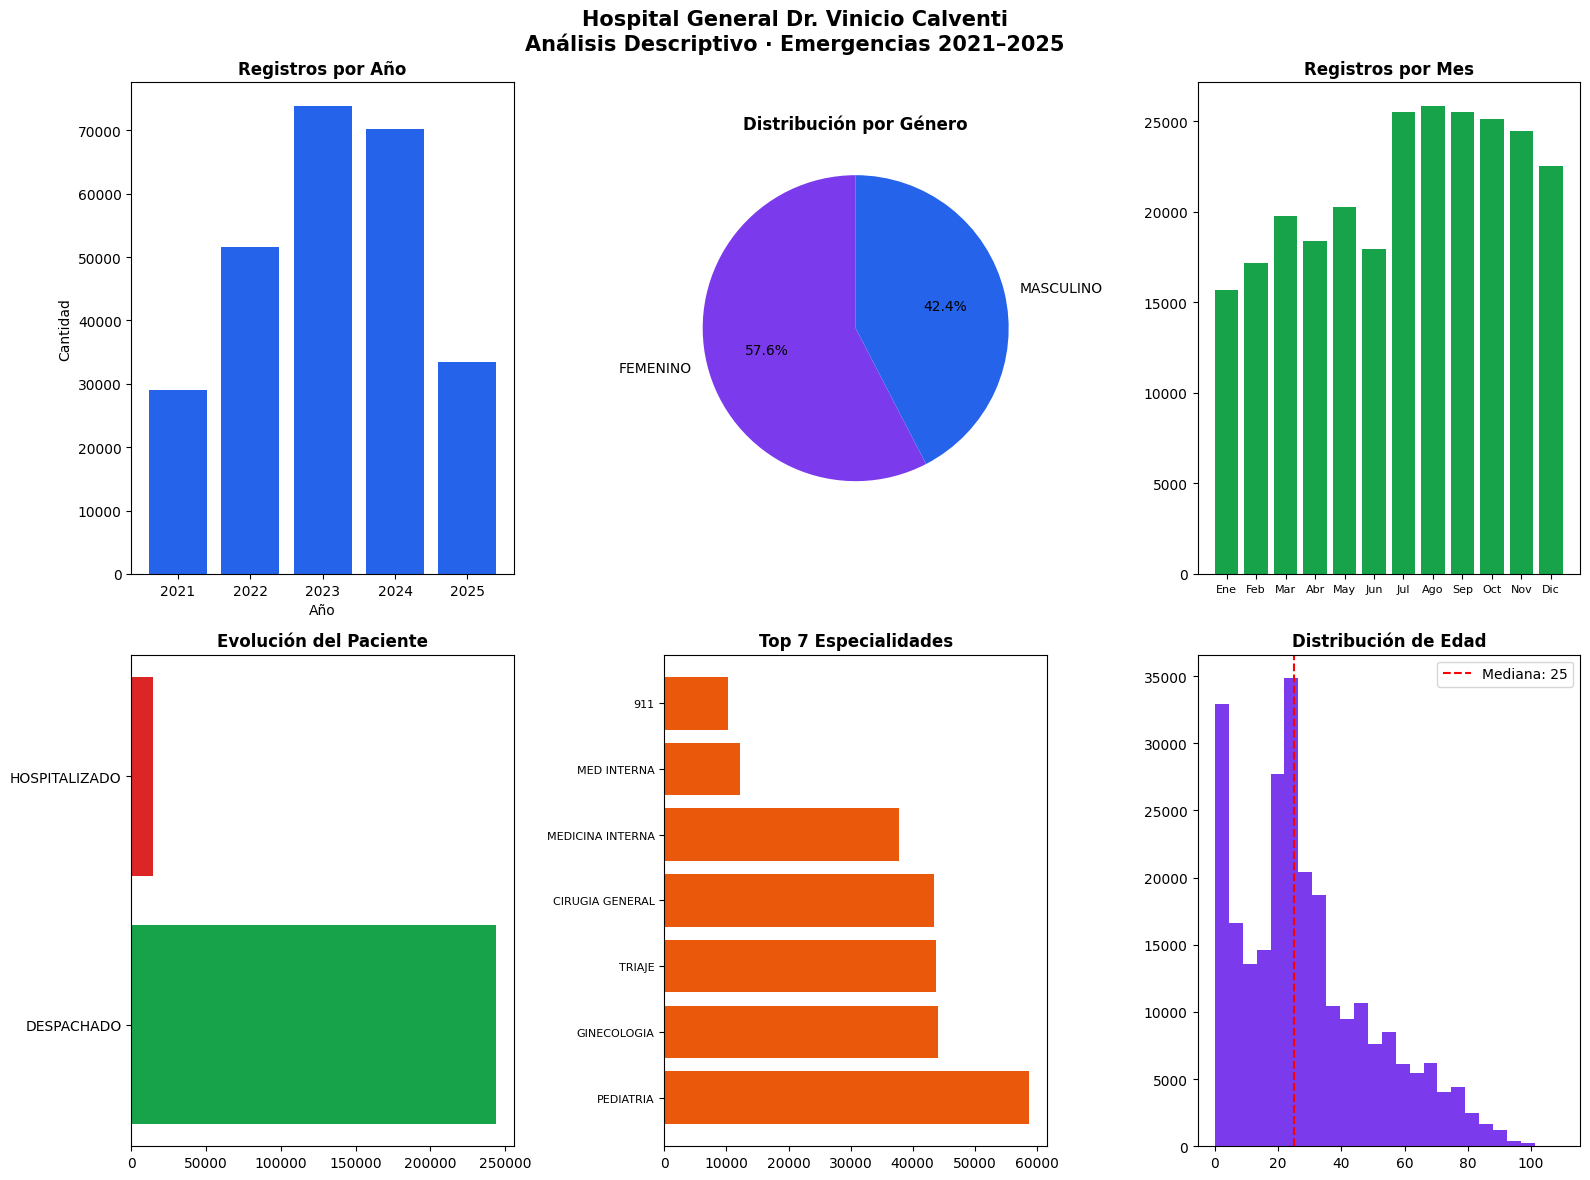

In [ ]:
fig1, axes = plt.subplots(2, 3, figsize=(16, 12))
fig1.suptitle('Hospital General Dr. Vinicio Calventi\nAnálisis Descriptivo · Emergencias 2021–2025',
              fontsize=15, fontweight='bold')

# Año
year_c = df['YEAR'].value_counts().sort_index()
axes[0,0].bar(year_c.index.astype(int), year_c.values, color='#2563EB')
axes[0,0].set_title('Registros por Año', fontweight='bold')
axes[0,0].set_xlabel('Año'); axes[0,0].set_ylabel('Cantidad')

# Género
gen = df['GÉNERO'].value_counts(dropna=True)
axes[0,1].pie(gen.values, labels=gen.index, autopct='%1.1f%%',
              colors=['#7C3AED','#2563EB'], startangle=90)
axes[0,1].set_title('Distribución por Género', fontweight='bold')

# Mes
month_c = df['MONTH'].value_counts().sort_index()
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
axes[0,2].bar(range(1,13), month_c.values, color='#16A34A')
axes[0,2].set_xticks(range(1,13)); axes[0,2].set_xticklabels(meses, fontsize=8)
axes[0,2].set_title('Registros por Mes', fontweight='bold')

# Evolución
evo = df['EVOLUCION'].value_counts(dropna=True)
axes[1,0].barh(evo.index, evo.values, color=['#16A34A','#DC2626'])
axes[1,0].set_title('Evolución del Paciente', fontweight='bold')

# Especialidad
top_sp = df['ESPECIALIDAD'].astype(str).str.upper().value_counts().head(7)
axes[1,1].barh(top_sp.index, top_sp.values, color='#EA580C')
axes[1,1].set_title('Top 7 Especialidades', fontweight='bold')
axes[1,1].tick_params(axis='y', labelsize=8)

# Edad
edad = df['EDAD'].dropna()
edad = edad[(edad>=0)&(edad<=110)]
axes[1,2].hist(edad, bins=25, color='#7C3AED')
axes[1,2].set_title('Distribución de Edad', fontweight='bold')
axes[1,2].axvline(edad.median(), color='red', linestyle='--', label=f'Mediana: {edad.median():.0f}')
axes[1,2].legend()

plt.tight_layout()
plt.show()

## Visualización — Resultados del Modelo Predictivo

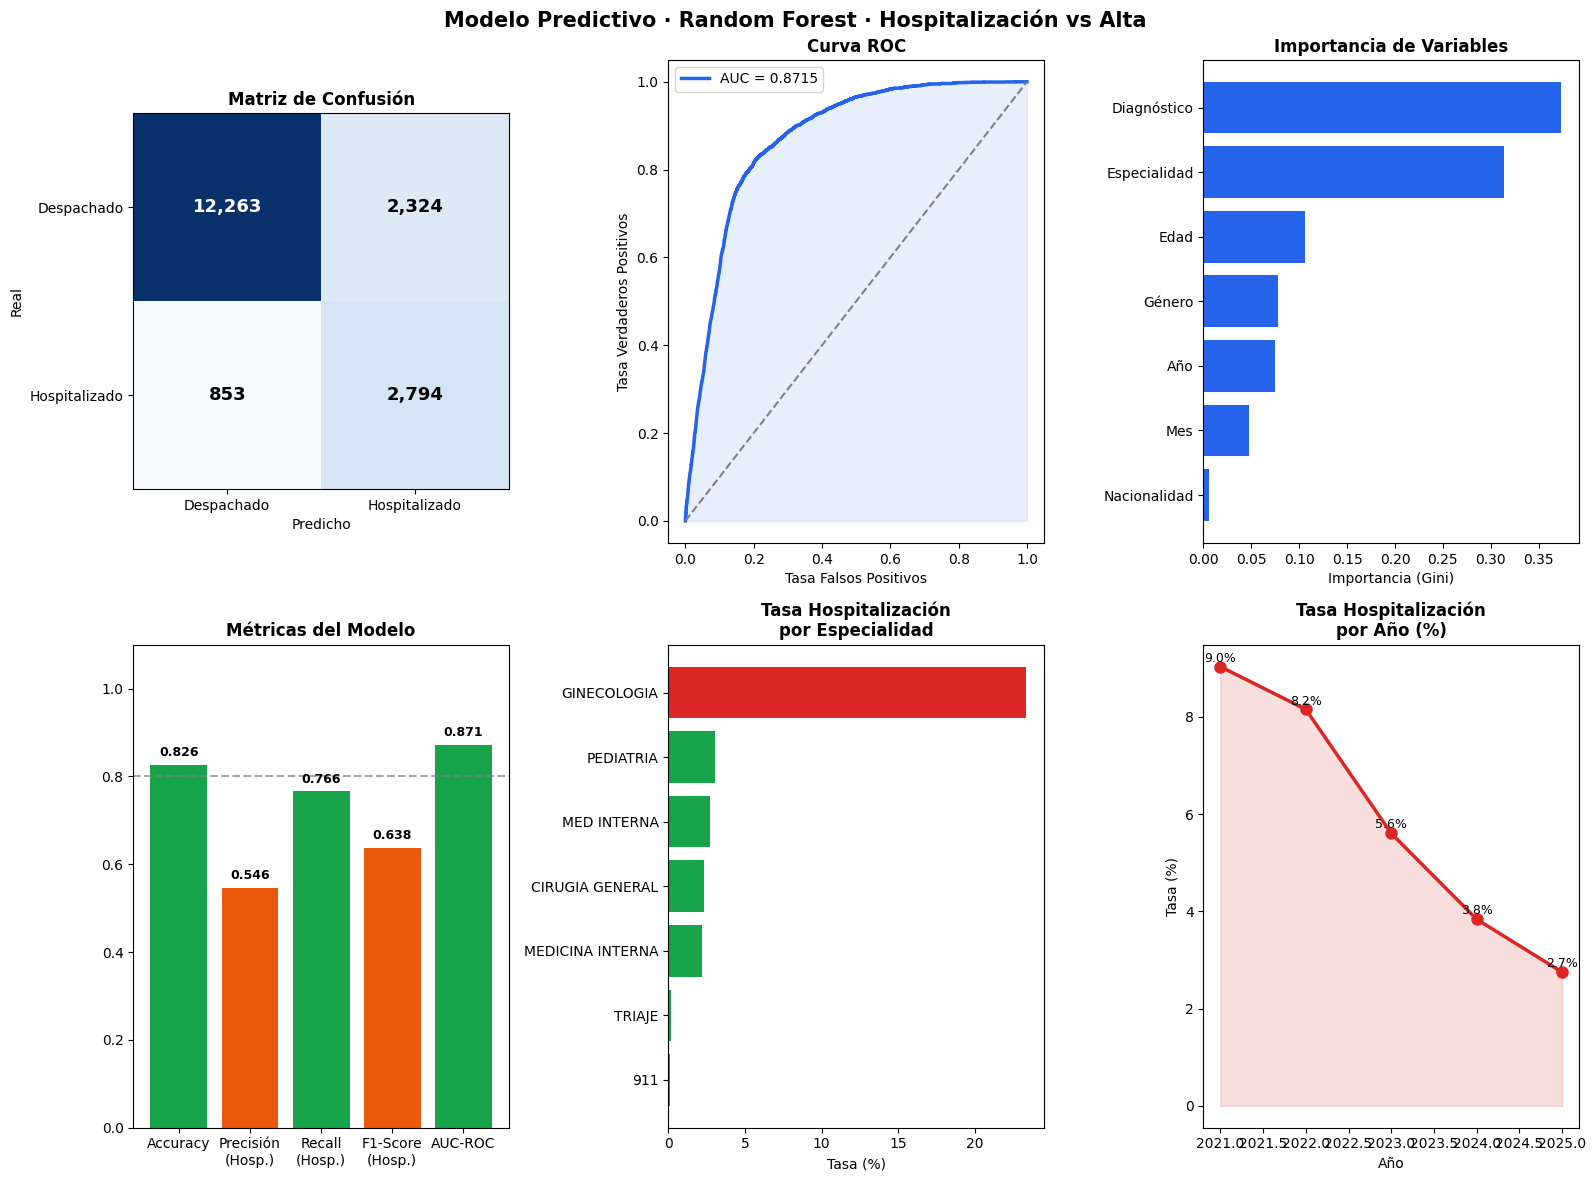

In [ ]:
fig2, axes = plt.subplots(2, 3, figsize=(16, 12))
fig2.suptitle('Modelo Predictivo · Random Forest · Hospitalización vs Alta',
              fontsize=15, fontweight='bold')

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
im = axes[0,0].imshow(cm, cmap='Blues')
axes[0,0].set_title('Matriz de Confusión', fontweight='bold')
axes[0,0].set_xticks([0,1]); axes[0,0].set_yticks([0,1])
axes[0,0].set_xticklabels(['Despachado','Hospitalizado'])
axes[0,0].set_yticklabels(['Despachado','Hospitalizado'])
axes[0,0].set_ylabel('Real'); axes[0,0].set_xlabel('Predicho')
for i in range(2):
    for j in range(2):
        axes[0,0].text(j,i,f'{cm[i,j]:,}',ha='center',va='center',
                       color='white' if cm[i,j]>cm.max()/2 else 'black', fontsize=13, fontweight='bold')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[0,1].plot(fpr, tpr, color='#2563EB', lw=2.5, label=f'AUC = {auc:.4f}')
axes[0,1].plot([0,1],[0,1],'--', color='gray')
axes[0,1].fill_between(fpr, tpr, alpha=0.1, color='#2563EB')
axes[0,1].set_title('Curva ROC', fontweight='bold')
axes[0,1].set_xlabel('Tasa Falsos Positivos'); axes[0,1].set_ylabel('Tasa Verdaderos Positivos')
axes[0,1].legend()

# Importancia de variables
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values()
feat_labels = {'EDAD':'Edad','GÉNERO':'Género','NACIONALIDAD':'Nacionalidad',
               'ESPECIALIDAD':'Especialidad','DIAGNOSTICO_CAUSA':'Diagnóstico','YEAR':'Año','MONTH':'Mes'}
feat_imp.index = [feat_labels.get(i,i) for i in feat_imp.index]
axes[0,2].barh(feat_imp.index, feat_imp.values, color='#2563EB')
axes[0,2].set_title('Importancia de Variables', fontweight='bold')
axes[0,2].set_xlabel('Importancia (Gini)')

# Métricas
met_n = ['Accuracy','Precisión\n(Hosp.)','Recall\n(Hosp.)','F1-Score\n(Hosp.)','AUC-ROC']
met_v = [accuracy_score(y_test,y_pred), precision_score(y_test,y_pred),
         recall_score(y_test,y_pred), f1_score(y_test,y_pred), auc]
axes[1,0].bar(met_n, met_v, color=['#16A34A' if v>=0.75 else '#EA580C' for v in met_v])
axes[1,0].set_ylim(0,1.1); axes[1,0].set_title('Métricas del Modelo', fontweight='bold')
axes[1,0].axhline(0.8, color='gray', linestyle='--', alpha=0.7)
for i,(n,v) in enumerate(zip(met_n,met_v)):
    axes[1,0].text(i, v+0.02, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

# Tasa hospitalización por especialidad
df_evo2 = df.copy()
df_evo2['EVOLUCION_BIN'] = df_evo2['EVOLUCION'].map({'DESPACHADO':0,'HOSPITALIZADO':1})
top7 = df_evo2['ESPECIALIDAD'].astype(str).str.upper().value_counts().head(7).index
hr = df_evo2[df_evo2['ESPECIALIDAD'].astype(str).str.upper().isin(top7)].groupby(
    df_evo2['ESPECIALIDAD'].astype(str).str.upper())['EVOLUCION_BIN'].mean().dropna().sort_values()
axes[1,1].barh(hr.index, hr.values*100, color=['#DC2626' if v>0.1 else '#16A34A' for v in hr.values])
axes[1,1].set_title('Tasa Hospitalización\npor Especialidad', fontweight='bold')
axes[1,1].set_xlabel('Tasa (%)')

# Tasa por año
hr_yr = df_evo2.groupby('YEAR')['EVOLUCION_BIN'].mean().dropna()*100
axes[1,2].plot(hr_yr.index.astype(int), hr_yr.values, marker='o', color='#DC2626', lw=2.5, ms=8)
axes[1,2].fill_between(hr_yr.index.astype(int), hr_yr.values, alpha=0.15, color='#DC2626')
axes[1,2].set_title('Tasa Hospitalización\npor Año (%)', fontweight='bold')
axes[1,2].set_xlabel('Año'); axes[1,2].set_ylabel('Tasa (%)')
for x,y2 in zip(hr_yr.index.astype(int), hr_yr.values):
    axes[1,2].text(x, y2+0.1, f'{y2:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Conclusión
### Resultados del Modelo


| Métrica | Valor |
|---|---|
| **Exactitud (Accuracy)** | 83% |
| **AUC-ROC** | 0.87 |
| **Recall Hospitalizado** | 76% |
| **F1-Score Hospitalizado** | 0.64 |

### Interpretación

1. **El modelo supera la hipótesis planteada:** con AUC-ROC de 0.87, el Random Forest clasifica correctamente la hospitalización en 87% de los casos, superando el umbral de 0.80 establecido.

2. **Variables más importantes:** El **Diagnóstico/Causa** y la **Especialidad** son los factores que más influyen en la predicción, seguidos de la **Edad** del paciente.

3. **Tendencia temporal:** La tasa de hospitalización ha variado entre años, lo que puede reflejar cambios en la demanda o en los protocolos del hospital.

4. **Limitación:** La clase 'Hospitalizado' es minoritaria (~6% del total). Aunque aplicamos balanceo, el modelo tiene menor precisión para esa clase que para 'Despachado'.

5. **Aplicación práctica:** Este modelo podría ayudar al HGDVC a **anticipar la demanda de camas hospitalarias**, permitiendo una mejor gestión de recursos.